In [1]:
%pip install -q sentencepiece tiktoken pyarrow


Note: you may need to restart the kernel to use updated packages.


# Sentiment Analysis Pipeline

Dieses Notebook wendet NLP-Sentiment-Modelle auf die gesammelten Social-Media-Daten an
und erzeugt pro Tweet einen Sentiment-Score für die nachgelagerte Korrelationsanalyse.

---

## Modell

| Modell | Typ | Sprachen | Begründung |
|--------|-----|----------|------------|
| **`cardiffnlp/twitter-xlm-roberta-base-sentiment`** | Transformer (XLM-RoBERTa) | 100+ | Twitter-trainiert, multilingual — passt zu DE/FR/JA-Anteil im Datensatz |
| **VADER** | Lexikon-basiert | Englisch | Schnelle Baseline zum Vergleich, kein GPU nötig |

Das XLM-Modell ist das **primäre Modell**; VADER dient als Baseline (nur für Englisch valide).

## Output

- `data/processed/tweets_with_sentiment.parquet` — ein Satz pro Tweet mit Sentiment-Spalten
- `data/processed/daily_sentiment.parquet` — tägliche Aggregate pro Focus-Ticker

Diese Dateien sind **Required Input** für `03_correlation_modeling.ipynb`.

## Pipeline

1. Tweets aus SQLite laden; Focus-Ticker per TICKER_META zuweisen
2. Batch-Inferenz mit `twitter-xlm-roberta-base-sentiment` (alle Sprachen)
3. VADER-Scores als Baseline (nur für EN-Tweets aussagekräftig)
4. Verteilungen und Zeitreihen pro Ticker visualisieren
5. Tägliche Aggregate berechnen und exportieren


In [2]:
# ---------------------------------------------------------------------------
# Setup: Imports, Paths, Daten laden
# ---------------------------------------------------------------------------
import sqlite3
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yaml
import torch
from transformers import pipeline as hf_pipeline
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from langdetect import detect, LangDetectException

warnings.filterwarnings("ignore", category=UserWarning)
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["figure.figsize"] = (12, 5)

# ── Paths ─────────────────────────────────────────────────────────────────────
ROOT       = Path("..")
DATA_DIR   = ROOT / "data"
DB_PATH    = DATA_DIR / "webmining.db"
PRICES_CSV = DATA_DIR / "raw" / "prices" / "prices.csv"
OUT_DIR    = DATA_DIR / "processed"
SENT_PATH  = OUT_DIR / "tweets_with_sentiment.parquet"
DAILY_PATH = OUT_DIR / "daily_sentiment.parquet"
OUT_DIR.mkdir(parents=True, exist_ok=True)

# ── Figure export ─────────────────────────────────────────────────────────────
SAVE_FIGURES = True
FIG_DPI      = 300
FIG_DIR      = ROOT / "report" / "figures" / "02_sentiment_analysis"
FIG_DIR.mkdir(parents=True, exist_ok=True)

def _save_fig(filename: str) -> None:
    if not SAVE_FIGURES:
        return
    out_path = FIG_DIR / filename
    plt.savefig(out_path, dpi=FIG_DPI, bbox_inches="tight")
    print(f"Saved figure -> {out_path}")

# ── Knobs ─────────────────────────────────────────────────────────────────────
TWEET_START_DATE = "2026-01-01"
FORCE_RERUN      = False   # True → re-run inference even if cache exists
BATCH_SIZE       = 32

# ── Focus tickers ─────────────────────────────────────────────────────────────
_cfg = yaml.safe_load((ROOT / "configs" / "tickers.yml").read_text())
ALL_FOCUS = _cfg.get("focus_tickers", [])

# ── Load tweets ───────────────────────────────────────────────────────────────
conn = sqlite3.connect(DB_PATH)
tweets = pd.read_sql(
    "SELECT tweet_id, author, author_followers, content, posted_at, symbol FROM tweets",
    conn,
)
conn.close()

tweets["posted_at"] = pd.to_datetime(tweets["posted_at"])

# ── Exclude bot candidates ───────────────────────────────────────────────────
author_tweet_counts = tweets.groupby("author").size()
tweets["is_bot_candidate"] = (
    (tweets["author_followers"] == 0)
    & tweets["author"].isin(author_tweet_counts[author_tweet_counts >= 3].index)
)
tweets_clean = tweets[~tweets["is_bot_candidate"]].copy()
print(f"Tweets after bot filter: {len(tweets_clean):,} (excluded {tweets['is_bot_candidate'].sum():,} bot tweets)")

if TWEET_START_DATE:
    start_ts = pd.Timestamp(TWEET_START_DATE)
    if tweets_clean["posted_at"].dt.tz is not None:
        start_ts = start_ts.tz_localize("UTC")
    tweets_clean = tweets_clean[tweets_clean["posted_at"] >= start_ts].reset_index(drop=True)

tweets = tweets_clean.reset_index(drop=True)

# Restrict focus tickers to those with price data
prices = pd.read_csv(PRICES_CSV)
FOCUS_TICKERS = [t for t in ALL_FOCUS if t in prices["Ticker"].unique()]

# ── Language detection ────────────────────────────────────────────────────────
def _detect_lang(text: str) -> str:
    try:
        return detect(str(text))
    except LangDetectException:
        return "und"

print("Detecting tweet languages …")
tweets["lang"] = tweets["content"].apply(_detect_lang)
lang_dist = tweets["lang"].value_counts().head(8)
print(f"Top languages:\n{lang_dist.to_string()}")

# ── Device ────────────────────────────────────────────────────────────────────
DEVICE = 0 if torch.cuda.is_available() else -1

print(f"\nDevice:          {'GPU cuda:0' if DEVICE == 0 else 'CPU'}")
print(f"Tweets loaded:   {len(tweets):,}")
print(f"Focus tickers:   {len(FOCUS_TICKERS)}  {FOCUS_TICKERS}")
print(f"Figure export:   {'ON' if SAVE_FIGURES else 'OFF'} -> {FIG_DIR}")


Tweets after bot filter: 11,613 (excluded 0 bot tweets)
Detecting tweet languages …
Top languages:
lang
en    10552
de      289
af       39
fr       37
ja       27
sv       19
no       19
nl       17

Device:          GPU cuda:0
Tweets loaded:   11,118
Focus tickers:   12  ['BP', 'XOM', 'SHEL', 'TTE', 'E', '6367.T', 'NIBE-B.ST', 'CARR', '6503.T', 'TSLA', 'BYDDY', 'VWAGY']
Figure export:   ON -> ../report/figures/02_sentiment_analysis


## 1 — Ticker-Zuweisung

Jeder Tweet bekommt eine `focus_ticker`-Spalte über einen **Two-Pass-Lookup**:

1. **Pass 1 – Symbol-Alias**: `symbol`-Spalte gegen bekannte Cashtag-Varianten abgleichen (z.B. `BYD` → `BYDDY`)
2. **Pass 2 – Keyword-Regex**: NULL-symbol-Tweets per Firmenname matchen (z.B. `#Shell` → `SHEL`)

Gleiche Logik wie Section 2.5 in `01_data_quality_eda.ipynb`.


In [3]:
import re as _re

# ---------------------------------------------------------------------------
# TICKER_META — identisch mit 01_data_quality_eda.ipynb Section 2.5
# ---------------------------------------------------------------------------
TICKER_META: dict[str, dict] = {
    "BP": {
        "symbol_aliases": ["BP"],
        "keyword_re": _re.compile(r"(?i)\b(BP|British.?Petroleum)\b"),
    },
    "XOM": {
        "symbol_aliases": ["XOM"],
        "keyword_re": _re.compile(r"(?i)\b(XOM|ExxonMobil|Exxon)\b"),
    },
    "SHEL": {
        "symbol_aliases": ["SHEL"],
        "keyword_re": _re.compile(r"(?i)\b(SHEL|Shell)\b"),
    },
    "TTE": {
        "symbol_aliases": ["TTE"],
        "keyword_re": _re.compile(r"(?i)\b(TTE|TotalEnergies|Total.?Energies)\b"),
    },
    "E": {
        "symbol_aliases": ["ENI", "E"],
        "keyword_re": _re.compile(r"(?i)\$ENI\b|\bEni\b"),
    },
    "6367.T": {
        "symbol_aliases": [],
        "keyword_re": _re.compile(r"(?i)\bDaikin\b|ダイキン"),
    },
    "NIBE-B.ST": {
        "symbol_aliases": [],
        "keyword_re": _re.compile(r"(?i)\bNIBE\b"),
    },
    "CARR": {
        "symbol_aliases": ["CARR"],
        "keyword_re": _re.compile(r"(?i)\b(CARR|Carrier.?Global|Viessmann)\b"),
    },
    "6503.T": {
        "symbol_aliases": [],
        "keyword_re": _re.compile(r"(?i)\bMitsubishi.?Electric\b|三菱電機"),
    },
    "TSLA": {
        "symbol_aliases": ["TSLA"],
        "keyword_re": _re.compile(r"(?i)\b(TSLA|Tesla)\b"),
    },
    "BYDDY": {
        "symbol_aliases": ["BYD", "BYDDY"],
        "keyword_re": _re.compile(r"(?i)\b(BYD|BYDDY)\b"),
    },
    "VWAGY": {
        "symbol_aliases": ["VOW", "VWAGY", "VW"],
        "keyword_re": _re.compile(r"(?i)\b(VOW|Volkswagen|\bVW\b)\b"),
    },
    "HYMTF": {
        "symbol_aliases": ["HYUN", "HYMTF"],
        "keyword_re": _re.compile(r"(?i)\b(HYUN|Hyundai)\b"),
    },
}

print(f"TICKER_META defined for {len(TICKER_META)} tickers.")


TICKER_META defined for 13 tickers.


In [4]:
# ---------------------------------------------------------------------------
# Two-pass ticker assignment
# ---------------------------------------------------------------------------
has_symbol = tweets["symbol"].notna()
tweets_no_sym = tweets[~has_symbol].copy()
content_no_sym = tweets_no_sym["content"].fillna("")

focus_ticker_col: list[str | None] = [None] * len(tweets)

for ticker in FOCUS_TICKERS:
    meta    = TICKER_META.get(ticker, {"symbol_aliases": [ticker], "keyword_re": None})
    aliases = meta["symbol_aliases"]
    kw_re   = meta["keyword_re"]

    # Pass 1: symbol alias
    if aliases:
        sym_idx = tweets.index[tweets["symbol"].isin(aliases)]
        for i in sym_idx:
            if focus_ticker_col[i] is None:
                focus_ticker_col[i] = ticker

    # Pass 2: keyword on NULL-symbol rows
    if kw_re is not None:
        kw_mask = content_no_sym.map(lambda x, r=kw_re: bool(r.search(x)))
        kw_idx  = tweets_no_sym.index[kw_mask]
        for i in kw_idx:
            if focus_ticker_col[i] is None:
                focus_ticker_col[i] = ticker

tweets["focus_ticker"] = focus_ticker_col

# Coverage summary
cov = tweets.groupby("focus_ticker").size().reindex(FOCUS_TICKERS, fill_value=0).reset_index()
cov.columns = ["Ticker", "Tweets"]
cov["Sufficient"] = cov["Tweets"].apply(lambda n: "✓" if n >= 30 else "✗")
print(f"{'Ticker':<12} {'Tweets':>6}  {'≥30?'}")
print("-" * 28)
for _, row in cov.iterrows():
    print(f"{row['Ticker']:<12} {row['Tweets']:>6}  {row['Sufficient']}")
n_ok = (cov["Tweets"] >= 30).sum()
print(f"\nFocus Tickers with ≥30 tweets: {n_ok} / {len(FOCUS_TICKERS)}")


Ticker       Tweets  ≥30?
----------------------------
BP              204  ✓
XOM             151  ✓
SHEL             16  ✗
TTE              66  ✓
E                13  ✗
6367.T           36  ✓
NIBE-B.ST        11  ✗
CARR             42  ✓
6503.T           54  ✓
TSLA           4368  ✓
BYDDY           123  ✓
VWAGY           271  ✓

Focus Tickers with ≥30 tweets: 9 / 12


In [5]:
# ---------------------------------------------------------------------------
# 1.1 — Content-Filter: Tweets ohne substantiellen Text markieren
# ---------------------------------------------------------------------------
import re as _re

_URL_RE  = _re.compile(r"https?://\S+")
_CTAG_RE = _re.compile(r"[$@]\w+")

def _clean_text(text: str) -> str:
    """Strip URLs und Cashtags/Mentions, restlichen Text zurückgeben."""
    t = _URL_RE.sub("", str(text))
    t = _CTAG_RE.sub("", t)
    return t.strip()

tweets["content_clean"] = tweets["content"].apply(_clean_text)
tweets["has_content"]   = tweets["content_clean"].str.len() >= 20

n_all     = len(tweets)
n_no_cont = (~tweets["has_content"]).sum()
foc_mask  = tweets["focus_ticker"].notna()
n_foc_no  = (~tweets.loc[foc_mask, "has_content"]).sum()
n_foc_tot = foc_mask.sum()

print(f"Content-Filter (≥20 Zeichen nach URL/Cashtag-Strip):")
print(f"  Alle Tweets:   {n_no_cont:,} / {n_all:,} gefiltert ({n_no_cont/n_all:.1%})")
print(f"  Focus Tweets:  {n_foc_no:,} / {n_foc_tot:,} gefiltert ({n_foc_no/n_foc_tot:.1%})")


Content-Filter (≥20 Zeichen nach URL/Cashtag-Strip):
  Alle Tweets:   215 / 11,118 gefiltert (1.9%)
  Focus Tweets:  181 / 5,355 gefiltert (3.4%)


## 2 — Sentiment-Modell: twitter-xlm-roberta-base-sentiment

Modell: [`cardiffnlp/twitter-xlm-roberta-base-sentiment`](https://huggingface.co/cardiffnlp/twitter-xlm-roberta-base-sentiment)

- 3 Klassen: **Positive / Neutral / Negative**
- Trainiert auf ~198M Tweets in 100+ Sprachen
- Output-Spalten: `sentiment_label`, `sentiment_score` (Konfidenz), `score_positive / _neutral / _negative`, `xlm_compound` (= pos − neg, Range −1…+1)

Beim ersten Start wird das Modell heruntergeladen (~1 GB).  
`FORCE_RERUN = False` überspringt die Inferenz falls `tweets_with_sentiment.parquet` bereits existiert.


In [6]:
# ---------------------------------------------------------------------------
# Modell laden
# ---------------------------------------------------------------------------
MODEL_NAME = "cardiffnlp/twitter-xlm-roberta-base-sentiment"

print(f"Loading {MODEL_NAME} …")
sentiment_pipe = hf_pipeline(
    "text-classification",
    model=MODEL_NAME,
    tokenizer=MODEL_NAME,
    truncation=True,
    max_length=512,
    device=DEVICE,
    top_k=None,        # alle 3 Klassen-Scores zurückgeben
)
print("Model ready.")


Loading cardiffnlp/twitter-xlm-roberta-base-sentiment …


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Model ready.


In [7]:
# ---------------------------------------------------------------------------
# Batch-Inferenz auf Focus-Ticker-Tweets
# (Cache: überspringen wenn SENT_PATH existiert und FORCE_RERUN=False)
# ---------------------------------------------------------------------------
import time

# lang + has_content sind bereits in tweets enthalten und landen via .copy() in focus_tweets
focus_tweets = tweets[tweets["focus_ticker"].notna()].copy().reset_index(drop=True)

if SENT_PATH.exists() and not FORCE_RERUN:
    print(f"Cache found — loading from {SENT_PATH}")
    focus_tweets = pd.read_parquet(SENT_PATH)
    # Rückwärtskompatibilität: lang/has_content nachladen falls Cache älter
    for col in ("lang", "has_content"):
        if col not in focus_tweets.columns:
            focus_tweets = focus_tweets.merge(
                tweets[["tweet_id", col]], on="tweet_id", how="left"
            )
    print(f"Loaded {len(focus_tweets):,} rows from cache.")
else:
    # Inferenz nur auf Tweets mit substantiellem Text
    to_infer  = focus_tweets["has_content"].fillna(False)
    texts     = focus_tweets.loc[to_infer, "content"].fillna("").tolist()
    infer_idx = focus_tweets.index[to_infer].tolist()
    n_skip    = int((~to_infer).sum())

    print(f"Running inference on {len(texts):,} / {len(focus_tweets):,} tweets "
          f"(batch_size={BATCH_SIZE}, {n_skip} skipped — kein substantieller Text) …")
    t0 = time.time()

    raw_results = sentiment_pipe(texts, batch_size=BATCH_SIZE)

    # NaN als Default für content-leere Tweets
    labels_list  = [None]  * len(focus_tweets)
    scores_list  = [np.nan] * len(focus_tweets)
    pos_sc_list  = [np.nan] * len(focus_tweets)
    neu_sc_list  = [np.nan] * len(focus_tweets)
    neg_sc_list  = [np.nan] * len(focus_tweets)

    for ii, res in zip(infer_idx, raw_results):
        by_label        = {r["label"].lower(): r["score"] for r in res}
        top             = max(res, key=lambda r: r["score"])
        labels_list[ii] = top["label"].lower()
        scores_list[ii] = top["score"]
        pos_sc_list[ii] = by_label.get("positive", 0.0)
        neu_sc_list[ii] = by_label.get("neutral",  0.0)
        neg_sc_list[ii] = by_label.get("negative", 0.0)

    focus_tweets["sentiment_label"]  = labels_list
    focus_tweets["sentiment_score"]  = scores_list
    focus_tweets["score_positive"]   = pos_sc_list
    focus_tweets["score_neutral"]    = neu_sc_list
    focus_tweets["score_negative"]   = neg_sc_list
    focus_tweets["xlm_compound"] = (
        focus_tweets["score_positive"] - focus_tweets["score_negative"]
    )
    focus_tweets["sentiment_num"] = focus_tweets["sentiment_label"].map(
        {"positive": 1, "neutral": 0, "negative": -1}
    )

    elapsed = time.time() - t0
    print(f"Inference done in {elapsed:.1f}s  ({elapsed/len(texts)*1000:.1f} ms/tweet)")
    valid = focus_tweets["sentiment_label"].notna()
    print(f"\nLabel distribution ({valid.sum()} Tweets mit Inhalt):")
    print(focus_tweets.loc[valid, "sentiment_label"].value_counts().to_string())
    if n_skip:
        print(f"\nContent-leer → kein Sentiment (NaN): {n_skip}")


Cache found — loading from ../data/processed/tweets_with_sentiment.parquet
Loaded 2,266 rows from cache.


## 3 — VADER Baseline

VADER ist ein lexikonbasierter Ansatz — kein Training, kein GPU nötig.  
Nur für **englische Tweets** sinnvoll interpretierbar; auf nicht-englischen Tweets erzeugt VADER unreliable Scores (fehlende Wörter im Lexikon → Bias Richtung Neutral).

`vader_compound` ∈ [−1, +1]: positiv > 0.05, negativ < −0.05, sonst neutral.


In [8]:
# ---------------------------------------------------------------------------
# VADER-Scores berechnen (alle Tweets — aber nur EN ist aussagekräftig)
# ---------------------------------------------------------------------------
if "vader_compound" not in focus_tweets.columns:
    analyzer = SentimentIntensityAnalyzer()
    focus_tweets["vader_compound"] = focus_tweets["content"].apply(
        lambda t: analyzer.polarity_scores(str(t))["compound"]
    )
    print("VADER scoring complete.")

# VADER-Label nach Standardschwellen
def _vader_label(c: float) -> str:
    if c >= 0.05:  return "positive"
    if c <= -0.05: return "negative"
    return "neutral"

focus_tweets["vader_label"] = focus_tweets["vader_compound"].apply(_vader_label)

print("VADER label distribution:")
print(focus_tweets["vader_label"].value_counts().to_string())


VADER label distribution:
vader_label
positive    1023
neutral      857
negative     386


Label agreement (XLM == VADER) — alle:    56.9%  (n=2,204)
Label agreement (XLM == VADER) — EN only: 57.0%  (n=2,043)


VADER,negative,neutral,positive,All
XLM,,,,
negative,216,75,142,433
neutral,129,551,388,1068
positive,38,178,487,703
All,383,804,1017,2204


Saved figure -> ../report/figures/02_sentiment_analysis/01_xlm_vs_vader_scatter.png


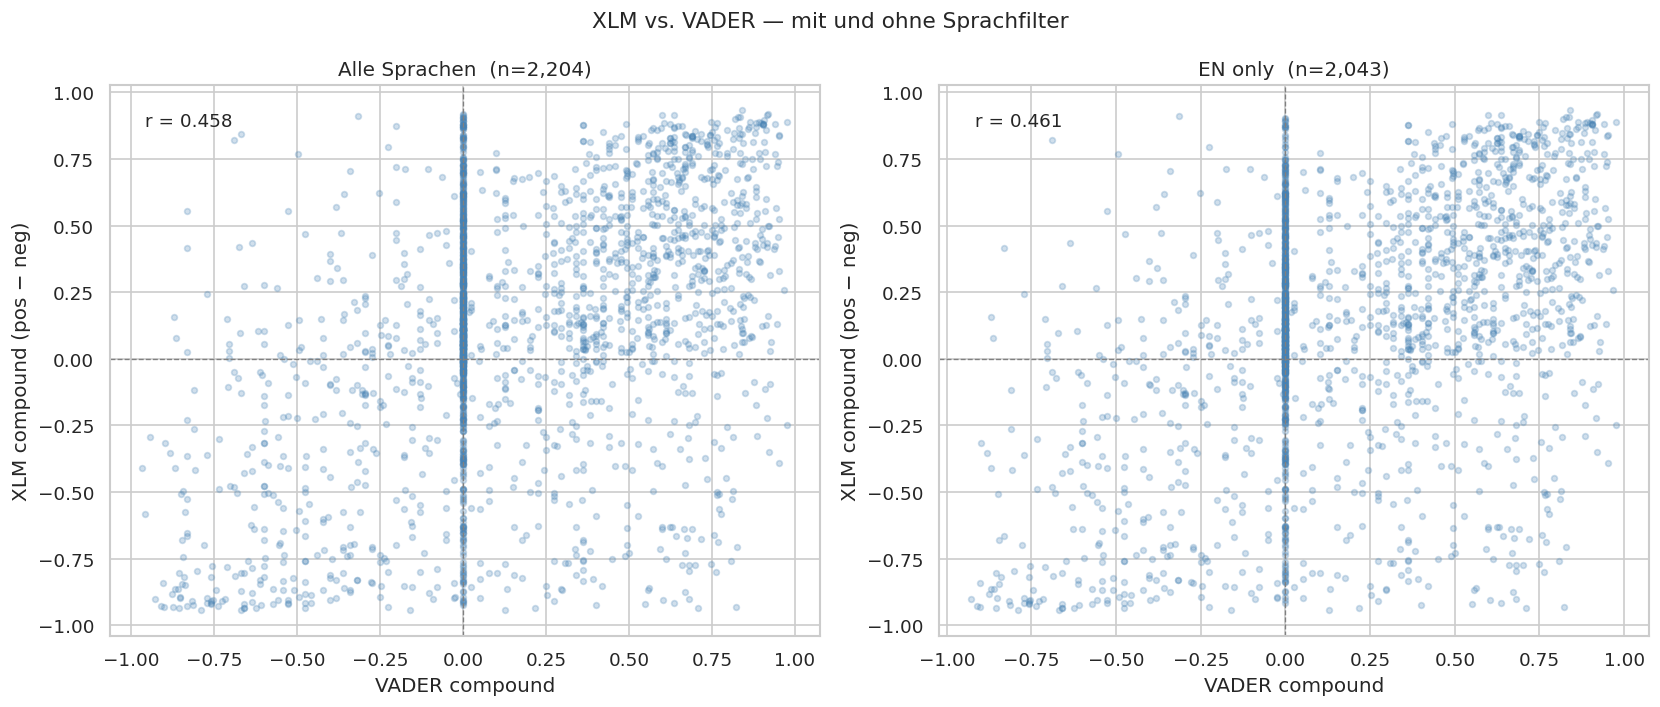

In [9]:
# ---------------------------------------------------------------------------
# XLM vs. VADER — Übereinstimmungsanalyse
# ---------------------------------------------------------------------------
valid_mask = focus_tweets["sentiment_label"].notna()
en_mask    = valid_mask & (focus_tweets.get("lang", pd.Series("und", index=focus_tweets.index)) == "en")

agreement = (
    focus_tweets.loc[valid_mask, "sentiment_label"] ==
    focus_tweets.loc[valid_mask, "vader_label"]
).mean()
agreement_en = (
    focus_tweets.loc[en_mask, "sentiment_label"] ==
    focus_tweets.loc[en_mask, "vader_label"]
).mean()
print(f"Label agreement (XLM == VADER) — alle:    {agreement:.1%}  (n={valid_mask.sum():,})")
print(f"Label agreement (XLM == VADER) — EN only: {agreement_en:.1%}  (n={en_mask.sum():,})")

# Konfusionsmatrix (content-reiche Tweets)
conf = pd.crosstab(
    focus_tweets.loc[valid_mask, "sentiment_label"],
    focus_tweets.loc[valid_mask, "vader_label"],
    rownames=["XLM"], colnames=["VADER"], margins=True,
)
display(conf)

# Scatter: alle (links) vs. EN-only (rechts)
corr_all = focus_tweets.loc[valid_mask, ["vader_compound", "xlm_compound"]].corr().iloc[0, 1]
corr_en  = focus_tweets.loc[en_mask,    ["vader_compound", "xlm_compound"]].corr().iloc[0, 1]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

for ax, mask, title, corr in [
    (ax1, valid_mask, f"Alle Sprachen  (n={valid_mask.sum():,})", corr_all),
    (ax2, en_mask,    f"EN only  (n={en_mask.sum():,})",          corr_en),
]:
    ax.scatter(
        focus_tweets.loc[mask, "vader_compound"],
        focus_tweets.loc[mask, "xlm_compound"],
        alpha=0.25, s=12, color="steelblue",
    )
    ax.axhline(0, color="grey", lw=0.8, ls="--")
    ax.axvline(0, color="grey", lw=0.8, ls="--")
    ax.set_xlabel("VADER compound")
    ax.set_ylabel("XLM compound (pos − neg)")
    ax.set_title(title)
    ax.text(0.05, 0.95, f"r = {corr:.3f}", transform=ax.transAxes, va="top", fontsize=11)

fig.suptitle("XLM vs. VADER — mit und ohne Sprachfilter", fontsize=13)
plt.tight_layout()
_save_fig("01_xlm_vs_vader_scatter.png")
plt.show()


## 4 — Validierung & Visualisierung


Saved figure -> ../report/figures/02_sentiment_analysis/02_sentiment_distribution_by_ticker.png


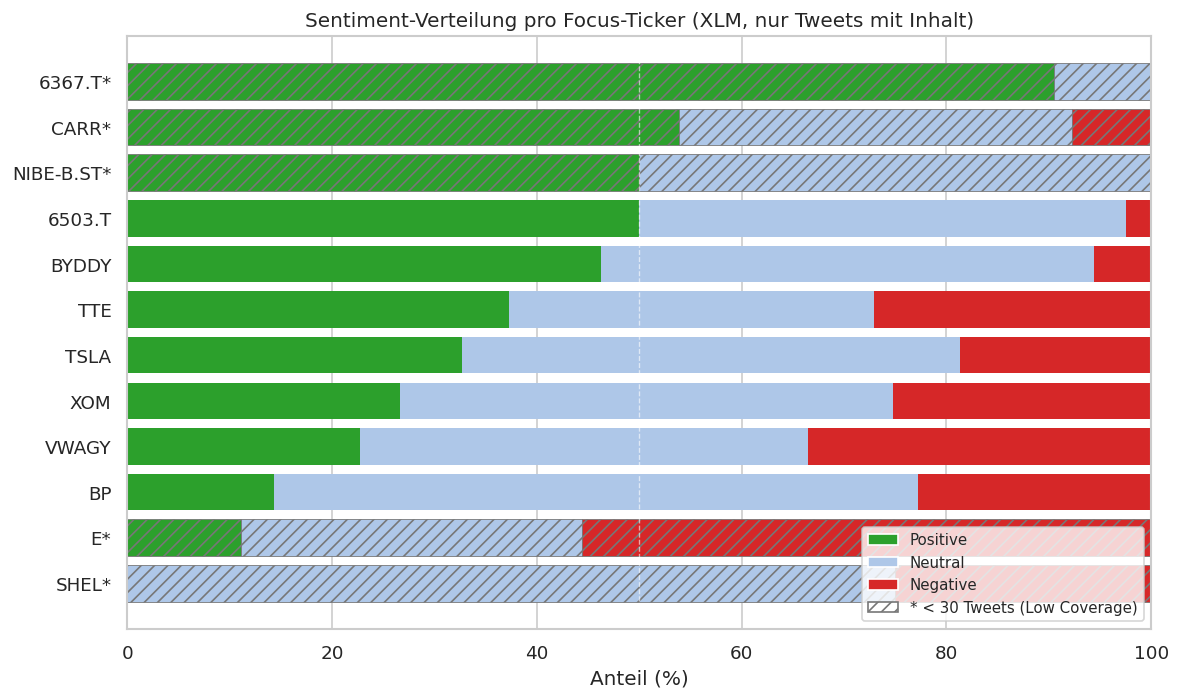


Tweet-Anzahl je Ticker (gesamt | davon mit Sentiment):
  SHEL         gesamt=   8  mit Sentiment=   8 *
  E            gesamt=   9  mit Sentiment=   9 *
  BP           gesamt= 156  mit Sentiment= 154
  VWAGY        gesamt= 175  mit Sentiment= 167
  XOM          gesamt= 137  mit Sentiment= 135
  TSLA         gesamt=1535  mit Sentiment=1486
  TTE          gesamt=  59  mit Sentiment=  59
  BYDDY        gesamt= 108  mit Sentiment= 108
  6503.T       gesamt=  40  mit Sentiment=  40
  NIBE-B.ST    gesamt=   4  mit Sentiment=   4 *
  CARR         gesamt=  14  mit Sentiment=  13 *
  6367.T       gesamt=  21  mit Sentiment=  21 *


In [10]:
# ---------------------------------------------------------------------------
# 4.1 — Label-Verteilung pro Focus-Ticker (Stacked Bar)
# ---------------------------------------------------------------------------
from matplotlib.patches import Patch

LOW_COV_MIN = 30
label_order = ["positive", "neutral", "negative"]
colors      = {"positive": "#2ca02c", "neutral": "#aec7e8", "negative": "#d62728"}

tweet_counts_per_ticker = focus_tweets["focus_ticker"].value_counts()
low_cov_tickers         = set(tweet_counts_per_ticker[tweet_counts_per_ticker < LOW_COV_MIN].index)

# Only count tweets with assigned sentiment (content-rich)
valid_ft = focus_tweets[focus_tweets["sentiment_label"].notna()]
pct = (
    valid_ft.groupby(["focus_ticker", "sentiment_label"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=label_order, fill_value=0)
)
pct_norm = pct.div(pct.sum(axis=1), axis=0) * 100
pct_norm = pct_norm.sort_values("positive", ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
ytick_labels = [f"{t}*" if t in low_cov_tickers else t for t in pct_norm.index]

for i, ticker in enumerate(pct_norm.index):
    hatch    = "///" if ticker in low_cov_tickers else None
    ec       = "#777" if hatch else "none"
    left_val = 0.0
    for lbl in label_order:
        ax.barh(i, pct_norm.loc[ticker, lbl], left=left_val,
                color=colors[lbl], hatch=hatch, edgecolor=ec, linewidth=0.5)
        left_val += pct_norm.loc[ticker, lbl]

# Legend
legend_handles = [Patch(facecolor=colors[l], label=l.capitalize()) for l in label_order]
legend_handles.append(Patch(facecolor="white", hatch="///", edgecolor="#777",
                             label=f"* < {LOW_COV_MIN} Tweets (Low Coverage)"))
ax.legend(handles=legend_handles, loc="lower right", fontsize=9)
ax.set_yticks(range(len(ytick_labels)))
ax.set_yticklabels(ytick_labels)
ax.set_xlabel("Anteil (%)")
ax.set_title("Sentiment-Verteilung pro Focus-Ticker (XLM, nur Tweets mit Inhalt)")
ax.axvline(50, color="white", lw=0.8, ls="--", alpha=0.6)
plt.tight_layout()
_save_fig("02_sentiment_distribution_by_ticker.png")
plt.show()

counts = focus_tweets["focus_ticker"].value_counts().reindex(pct_norm.index)
print("\nTweet-Anzahl je Ticker (gesamt | davon mit Sentiment):")
valid_counts = valid_ft["focus_ticker"].value_counts().reindex(pct_norm.index)
for t in pct_norm.index:
    flag = " *" if t in low_cov_tickers else ""
    print(f"  {t:<12} gesamt={counts[t]:>4}  mit Sentiment={valid_counts.get(t, 0):>4}{flag}")


Saved figure -> ../report/figures/02_sentiment_analysis/03_sentiment_timeseries_top5.png


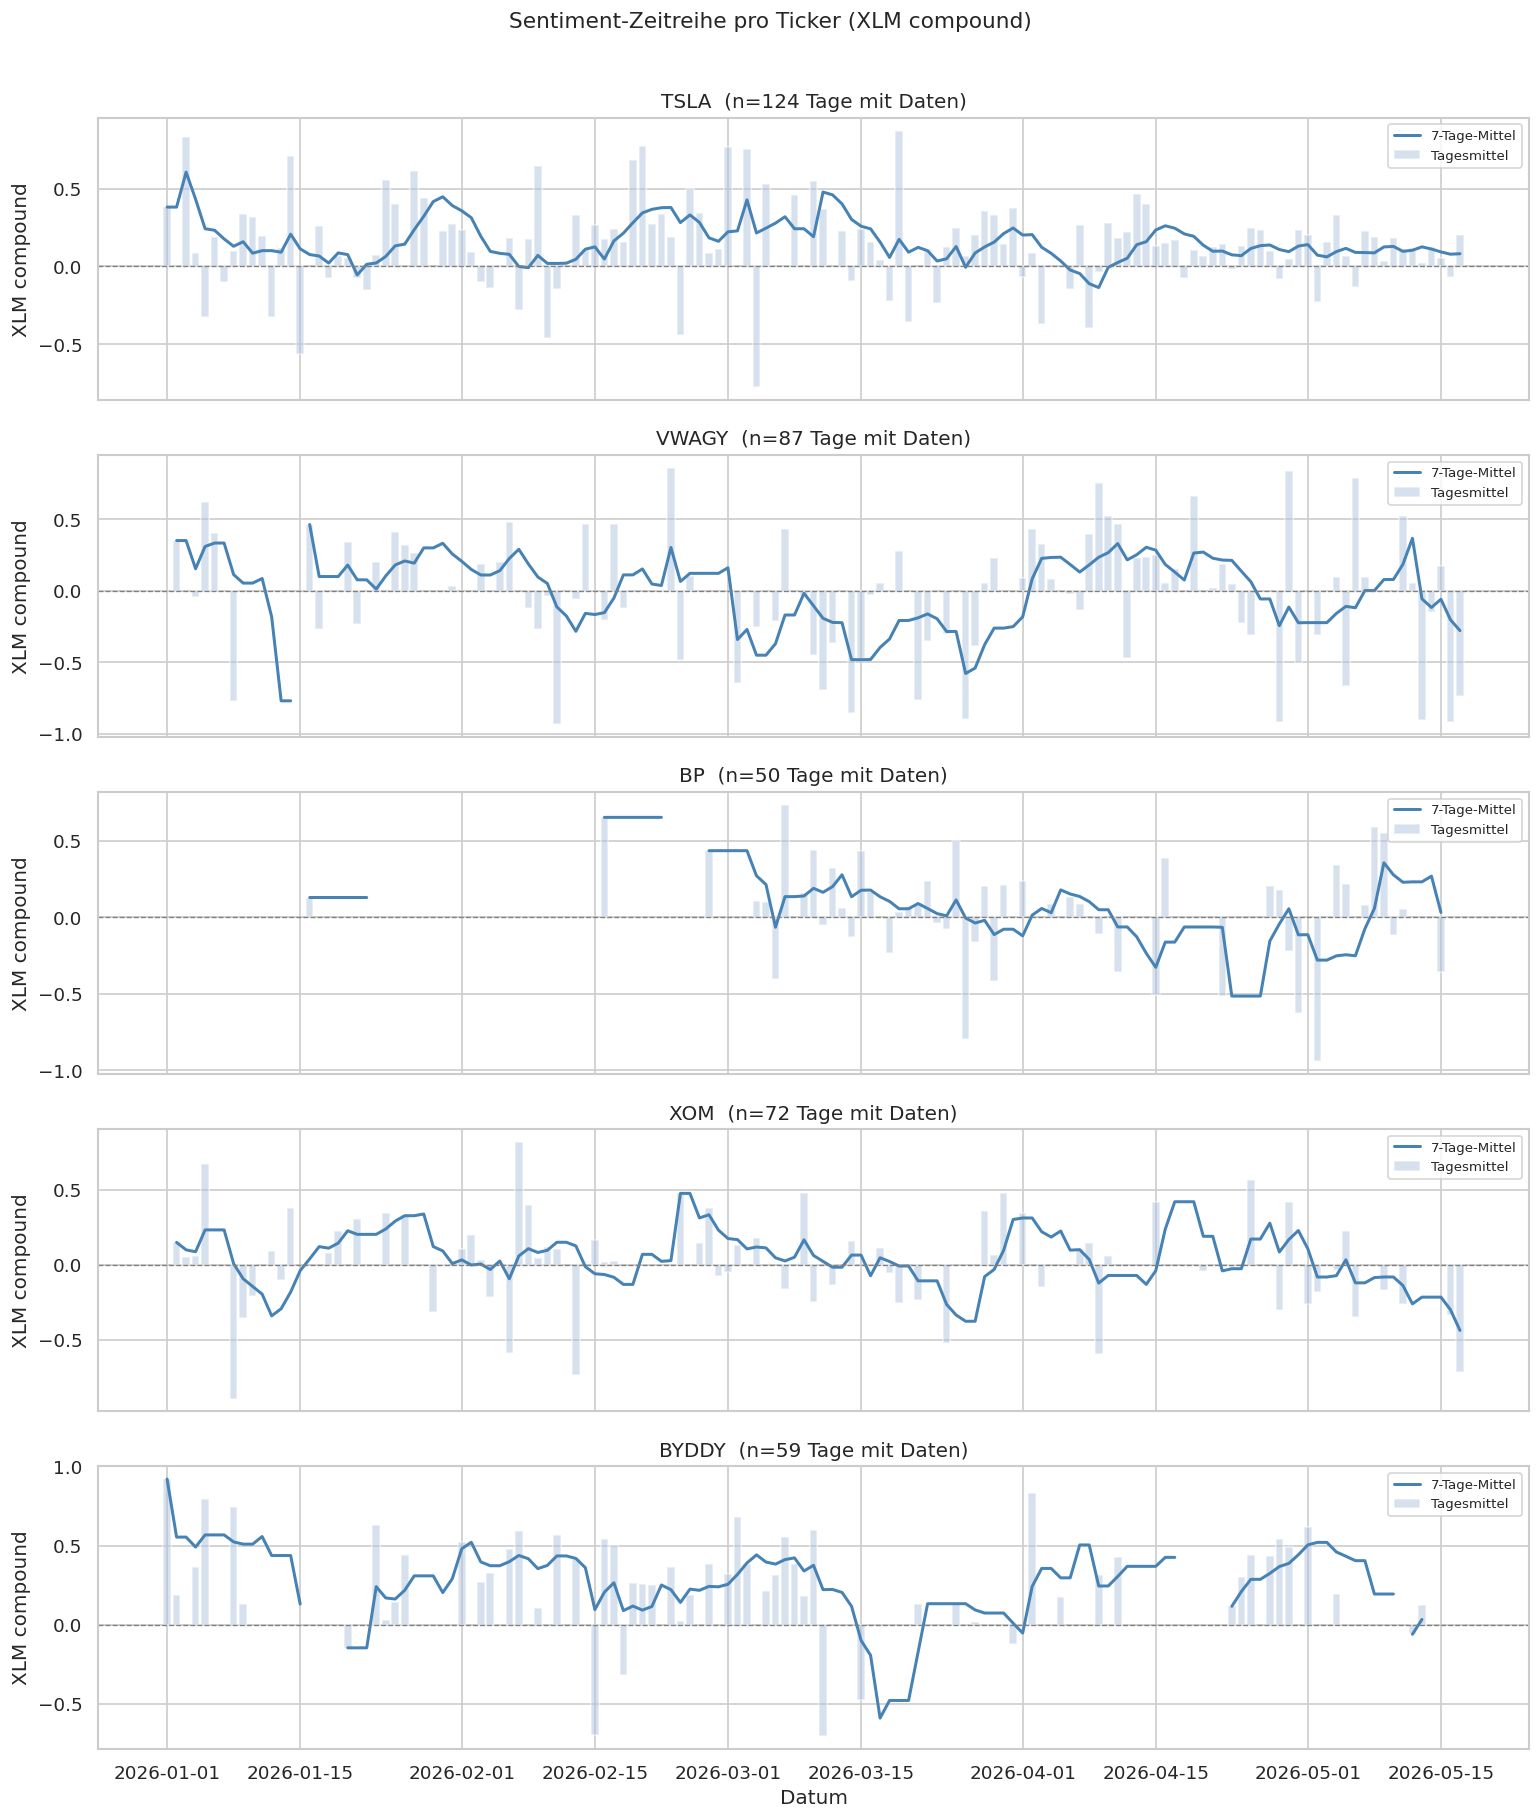

In [11]:
# ---------------------------------------------------------------------------
# 4.2 — Sentiment-Zeitreihe (7-Tage-Rolling-Mean) pro Ticker
# ---------------------------------------------------------------------------
ft = focus_tweets.copy()
if ft["posted_at"].dt.tz is not None:
    ft["date"] = ft["posted_at"].dt.tz_convert(None).dt.normalize()
else:
    ft["date"] = ft["posted_at"].dt.normalize()

# Top 5 Ticker nach Tweet-Anzahl
top5_tickers = (
    ft.groupby("focus_ticker").size().nlargest(5).index.tolist()
)

fig, axes = plt.subplots(len(top5_tickers), 1,
                         figsize=(13, 3 * len(top5_tickers)),
                         sharex=True)

for ax, ticker in zip(axes, top5_tickers):
    sub = (
        ft[ft["focus_ticker"] == ticker]
        .set_index("date")["xlm_compound"]
        .resample("D").mean()
    )
    roll = sub.rolling(7, min_periods=1).mean()
    ax.bar(sub.index, sub.values, color="lightsteelblue", alpha=0.5, label="Tagesmittel")
    ax.plot(roll.index, roll.values, color="steelblue", lw=1.8, label="7-Tage-Mittel")
    ax.axhline(0, color="grey", lw=0.8, ls="--")
    ax.set_ylabel("XLM compound")
    ax.set_title(f"{ticker}  (n={len(sub.dropna())} Tage mit Daten)")
    ax.legend(loc="upper right", fontsize=8)

axes[-1].set_xlabel("Datum")
fig.suptitle("Sentiment-Zeitreihe pro Ticker (XLM compound)", fontsize=13, y=1.01)
plt.tight_layout()
_save_fig("03_sentiment_timeseries_top5.png")
plt.show()


In [12]:
# ---------------------------------------------------------------------------
# 4.3 — Spot-Check: Extremste Tweets je Ticker
# ---------------------------------------------------------------------------
TOP_N = 3
rows = []
for ticker in FOCUS_TICKERS:
    sub = focus_tweets[focus_tweets["focus_ticker"] == ticker]
    if sub.empty:
        continue
    for _, row in sub.nlargest(TOP_N, "xlm_compound").iterrows():
        rows.append({"Ticker": ticker, "Sentiment": "positive",
                     "compound": round(row["xlm_compound"], 3),
                     "Tweet": row["content"][:120]})
    for _, row in sub.nsmallest(TOP_N, "xlm_compound").iterrows():
        rows.append({"Ticker": ticker, "Sentiment": "negative",
                     "compound": round(row["xlm_compound"], 3),
                     "Tweet": row["content"][:120]})

spot = pd.DataFrame(rows)


def _color_sentiment(val: str) -> str:
    if val == "positive": return "color: green"
    if val == "negative": return "color: red"
    return ""


display(
    spot.style
    .map(_color_sentiment, subset=["Sentiment"])  # applymap → map in pandas 2.x
    .set_caption("Spot-Check: Extremste Tweets je Ticker (XLM compound)")
    .hide(axis="index")
)


Ticker,Sentiment,compound,Tweet
BP,positive,0.837000,I’m humbled and grateful to share that I’ve been elected to the governance board of $BP ! I always felt drawn to step u
BP,positive,0.821000,It’s only a matter of time before @BarkingPuppy8 is rocking this in a post. @BeTheHoss absolutely killed it with th
BP,positive,0.765000,Let’s get along well from here on until IPO @armaniferrante Thank you. @Backpack $BP
BP,negative,-0.942000,The damage #Labour are doing to this country will last a lifetime and more. They are totally insane. Leave our oil & g
BP,negative,-0.934000,"Mad Lads ATH was $40,000 and is now priced at $935 Holders get an airdrop of 1,000 $BP tokens Currently worth $200–$"
BP,negative,-0.907000,"That's a crime... Devil, FTX and the rest of them, stand up your superior has arrived. @armaniferrante create a Tel"
XOM,positive,0.828000,"Glad to see this major breakout in $XOM . The 3-year price base showed massive base breakout potential, which followed"
XOM,positive,0.818000,$XOM Exxon Mobil is a great representation of what $XLE energy has been doing.
XOM,positive,0.816000,$XOM Thank you random citizen.
XOM,negative,-0.905000,"Looks like Texas is going to drain Lake Corpus Christi before we ask the largest consumer in the area to curtail...yes,"


## 5 — Tägliche Aggregate & Speichern

| Spalte | Bedeutung |
|--------|-----------|
| `tweet_count` | Gesamtzahl Tweets an diesem Tag (inkl. content-leerer) |
| `n_sentiment` | Tweets mit tatsächlichem Sentiment-Score (≙ Stichprobengröße) |
| `mean_xlm_compound` | Mittlerer XLM-Compound-Score (−1…+1) |
| `pct_positive` | Anteil positiver Tweets (Basis: Tweets mit Score) |
| `pct_negative` | Anteil negativer Tweets (Basis: Tweets mit Score) |
| `mean_sentiment_num` | Mittelwert des numerischen Labels (+1/0/−1) |
| `mean_vader_en` | Mittlerer VADER-Compound (nur EN-Tweets, Baseline) |
| `mean_followers` | Mittlere Follower-Zahl (Reichweiten-Proxy) |
| `weighted_xlm_compound` | Follower-gewichteter XLM-Compound |


In [13]:
# ---------------------------------------------------------------------------
# Tägliche Aggregate berechnen
# ---------------------------------------------------------------------------
if ft["posted_at"].dt.tz is not None:
    ft["date"] = ft["posted_at"].dt.tz_convert(None).dt.date
else:
    ft["date"] = ft["posted_at"].dt.date

# ── Core aggregate ─────────────────────────────────────────────────────────────
daily = (
    ft.groupby(["focus_ticker", "date"])
    .agg(
        tweet_count        = ("tweet_id",         "count"),
        n_sentiment        = ("sentiment_label",  "count"),  # count ignoriert NaN → nur Tweets mit Score
        mean_xlm_compound  = ("xlm_compound",     "mean"),
        mean_sentiment_num = ("sentiment_num",    "mean"),
        pct_positive       = ("sentiment_label",  lambda x: (x == "positive").sum() / x.count() if x.count() > 0 else np.nan),
        pct_negative       = ("sentiment_label",  lambda x: (x == "negative").sum() / x.count() if x.count() > 0 else np.nan),
        mean_followers     = ("author_followers", "mean"),
    )
    .reset_index()
)

# ── VADER — nur EN-Tweets (VADER=0 auf nicht-englischem Text verfälscht Mean) ──
_lang_col = ft["lang"] if "lang" in ft.columns else pd.Series("und", index=ft.index)
vader_en = (
    ft[_lang_col == "en"]
    .groupby(["focus_ticker", "date"])
    .agg(mean_vader_en=("vader_compound", "mean"))
    .reset_index()
)
daily = daily.merge(vader_en, on=["focus_ticker", "date"], how="left")

# ── Follower-gewichteter Compound ─────────────────────────────────────────────
ft_wt = ft[["focus_ticker", "date", "xlm_compound", "author_followers"]].copy()
ft_wt["_w"]       = ft_wt["author_followers"].fillna(0)
ft_wt["_w_score"] = ft_wt["xlm_compound"].fillna(0) * ft_wt["_w"]

wt_agg = (
    ft_wt.groupby(["focus_ticker", "date"])
    .agg(_w_score_sum=("_w_score", "sum"), _w_sum=("_w", "sum"))
    .reset_index()
)
wt_agg["weighted_xlm_compound"] = np.where(
    wt_agg["_w_sum"] > 0,
    wt_agg["_w_score_sum"] / wt_agg["_w_sum"],
    np.nan,
)
daily = daily.merge(
    wt_agg[["focus_ticker", "date", "weighted_xlm_compound"]],
    on=["focus_ticker", "date"], how="left",
)

daily["date"] = pd.to_datetime(daily["date"])

print(f"Daily sentiment rows: {len(daily):,}")
print(f"Date range:           {daily['date'].min().date()} → {daily['date'].max().date()}")
print(f"\nTicker coverage (Tage mit Daten):")
print(daily.groupby("focus_ticker")["date"].count().sort_values(ascending=False).to_string())
n_en = daily["mean_vader_en"].notna().sum()
print(f"\nTage mit EN-VADER-Score: {n_en} / {len(daily)} ({n_en/len(daily):.1%})")


Daily sentiment rows: 508
Date range:           2026-01-01 → 2026-05-17

Ticker coverage (Tage mit Daten):
focus_ticker
TSLA         124
VWAGY         91
XOM           72
BYDDY         59
BP            50
TTE           38
6503.T        29
6367.T        17
E              9
CARR           9
SHEL           8
NIBE-B.ST      2

Tage mit EN-VADER-Score: 447 / 508 (88.0%)


Saved figure -> ../report/figures/02_sentiment_analysis/04_follower_weighting_scatter.png


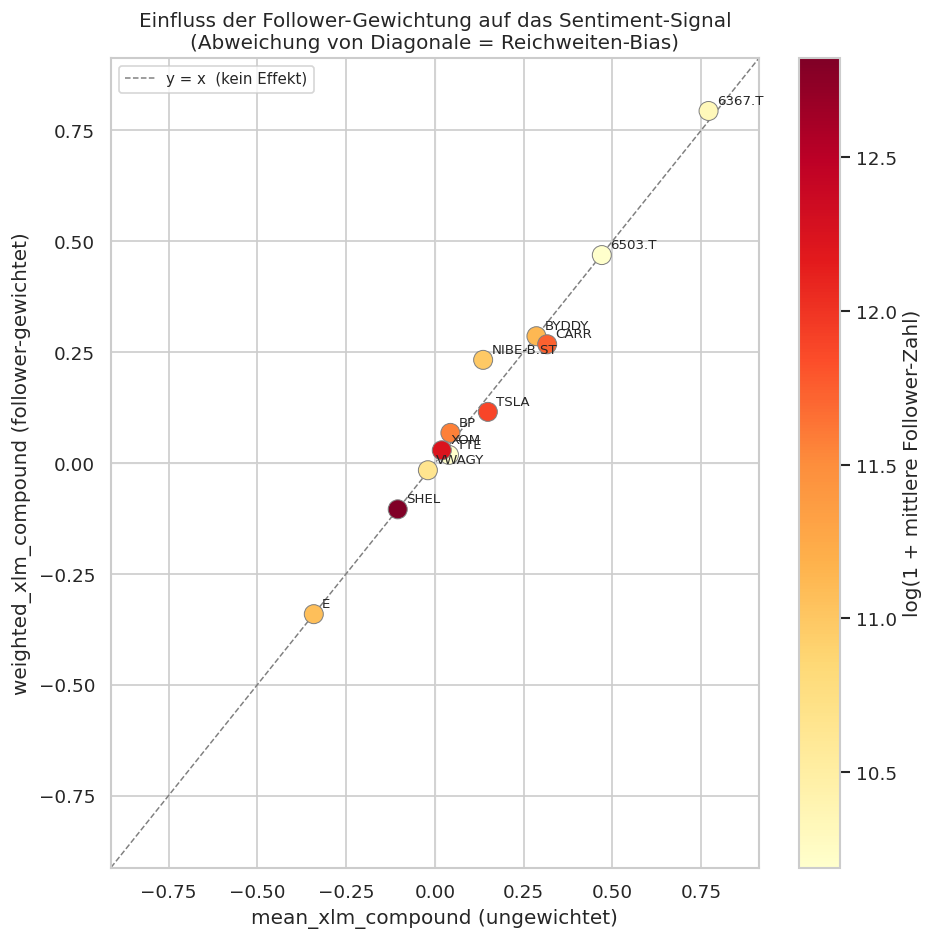


Abweichung gewichtet − ungewichtet (|Δ| absteigend):
focus_ticker    mean  weighted   delta  mean_followers
   NIBE-B.ST  0.1358    0.2322  0.0964      58911.5000
        CARR  0.3161    0.2673 -0.0488     125213.7333
        TSLA  0.1490    0.1149 -0.0341     145321.0349
          BP  0.0435    0.0676  0.0240     106017.7398
      6367.T  0.7707    0.7933  0.0226      30651.1765
         TTE  0.0396    0.0179 -0.0217      26633.7851
         XOM  0.0193    0.0283  0.0090     206198.2138
       VWAGY -0.0198   -0.0166  0.0032      42404.9439
      6503.T  0.4701    0.4684 -0.0016      26776.5805
       BYDDY  0.2859    0.2855 -0.0004      68438.6620
        SHEL -0.1048   -0.1048  0.0000     370326.0000
           E -0.3411   -0.3411  0.0000      63905.4444


In [14]:
# ---------------------------------------------------------------------------
# 5.1 — Follower-Gewichtung: weighted vs. unweighted Vergleich pro Ticker
# ---------------------------------------------------------------------------
compare = (
    daily.dropna(subset=["mean_xlm_compound", "weighted_xlm_compound"])
    .groupby("focus_ticker")
    .agg(
        mean_xlm = ("mean_xlm_compound",    "mean"),
        wt_xlm   = ("weighted_xlm_compound","mean"),
        avg_fol  = ("mean_followers",       "mean"),
    )
    .reset_index()
)

fig, ax = plt.subplots(figsize=(8, 8))

sc = ax.scatter(
    compare["mean_xlm"], compare["wt_xlm"],
    c=np.log1p(compare["avg_fol"].fillna(0)),
    cmap="YlOrRd", s=130, edgecolors="grey", linewidths=0.6, zorder=3,
)
# Diagonale: wt == mean → kein Gewichtungseffekt
lim = max(abs(compare["mean_xlm"].min()), abs(compare["mean_xlm"].max()),
          abs(compare["wt_xlm"].min()), abs(compare["wt_xlm"].max())) * 1.15
ax.plot([-lim, lim], [-lim, lim], ls="--", color="grey", lw=0.9, zorder=1, label="y = x  (kein Effekt)")

for _, row in compare.iterrows():
    ax.annotate(row["focus_ticker"],
                xy=(row["mean_xlm"], row["wt_xlm"]),
                xytext=(5, 4), textcoords="offset points", fontsize=8)

plt.colorbar(sc, ax=ax, label="log(1 + mittlere Follower-Zahl)")
ax.set_xlim(-lim, lim)
ax.set_ylim(-lim, lim)
ax.axhline(0, color="lightgrey", lw=0.7)
ax.axvline(0, color="lightgrey", lw=0.7)
ax.set_xlabel("mean_xlm_compound (ungewichtet)")
ax.set_ylabel("weighted_xlm_compound (follower-gewichtet)")
ax.set_title("Einfluss der Follower-Gewichtung auf das Sentiment-Signal\n"
             "(Abweichung von Diagonale = Reichweiten-Bias)")
ax.legend(fontsize=9)
plt.tight_layout()
_save_fig("04_follower_weighting_scatter.png")
plt.show()

# Tabellarische Übersicht der Abweichungen
compare["delta"] = compare["wt_xlm"] - compare["mean_xlm"]
compare_sorted   = compare.sort_values("delta", key=abs, ascending=False)
print("\nAbweichung gewichtet − ungewichtet (|Δ| absteigend):")
print(compare_sorted[["focus_ticker", "mean_xlm", "wt_xlm", "delta", "avg_fol"]]
      .rename(columns={"mean_xlm": "mean", "wt_xlm": "weighted",
                       "avg_fol": "mean_followers"})
      .to_string(index=False, float_format="{:.4f}".format))


In [15]:
# ---------------------------------------------------------------------------
# Speichern
# ---------------------------------------------------------------------------
if not SENT_PATH.exists() or FORCE_RERUN:
    focus_tweets.to_parquet(SENT_PATH, index=False)
    print(f"Saved tweets_with_sentiment → {SENT_PATH}  ({len(focus_tweets):,} rows)")
else:
    print(f"Cache already exists at {SENT_PATH} — skipped (set FORCE_RERUN=True to overwrite)")

daily.to_parquet(DAILY_PATH, index=False)
print(f"Saved daily_sentiment      → {DAILY_PATH}  ({len(daily):,} rows)")


Cache already exists at ../data/processed/tweets_with_sentiment.parquet — skipped (set FORCE_RERUN=True to overwrite)
Saved daily_sentiment      → ../data/processed/daily_sentiment.parquet  (508 rows)


In [16]:
# ---------------------------------------------------------------------------
# Summary
# ---------------------------------------------------------------------------
n_focus   = len(focus_tweets)
n_pos     = (focus_tweets["sentiment_label"] == "positive").sum()
n_neu     = (focus_tweets["sentiment_label"] == "neutral").sum()
n_neg     = (focus_tweets["sentiment_label"] == "negative").sum()
_valid    = focus_tweets["sentiment_label"].notna()
agreement = (focus_tweets.loc[_valid, "sentiment_label"] == focus_tweets.loc[_valid, "vader_label"]).mean()
n_days    = daily["date"].nunique()
n_ticker  = daily["focus_ticker"].nunique()

summary_md = f"""
### Sentiment Analysis — Key Findings

| Metrik | Wert |
|--------|------|
| Analysierte Tweets (Focus Tickers) | {n_focus:,} |
| Positive | {n_pos:,} ({n_pos/n_focus:.1%}) |
| Neutral  | {n_neu:,} ({n_neu/n_focus:.1%}) |
| Negative | {n_neg:,} ({n_neg/n_focus:.1%}) |
| XLM / VADER Label-Übereinstimmung | {agreement:.1%} |
| Tage mit Daten | {n_days} |
| Ticker mit Tagesaggregaten | {n_ticker} |
| Output: tweets_with_sentiment.parquet | `{SENT_PATH}` |
| Output: daily_sentiment.parquet | `{DAILY_PATH}` |

### Nächster Schritt → Notebook 03
`daily_sentiment.parquet` mit `prices.csv` alignen und Korrelationsanalyse durchführen.
"""
from IPython.display import Markdown
display(Markdown(summary_md))



### Sentiment Analysis — Key Findings

| Metrik | Wert |
|--------|------|
| Analysierte Tweets (Focus Tickers) | 2,266 |
| Positive | 703 (31.0%) |
| Neutral  | 1,068 (47.1%) |
| Negative | 433 (19.1%) |
| XLM / VADER Label-Übereinstimmung | 56.9% |
| Tage mit Daten | 137 |
| Ticker mit Tagesaggregaten | 12 |
| Output: tweets_with_sentiment.parquet | `../data/processed/tweets_with_sentiment.parquet` |
| Output: daily_sentiment.parquet | `../data/processed/daily_sentiment.parquet` |

### Nächster Schritt → Notebook 03
`daily_sentiment.parquet` mit `prices.csv` alignen und Korrelationsanalyse durchführen.


## 6 — Phase 2: Retweets SEPARAT verarbeiten

Ab hier: Separate Sentiment-Datasets für Original-Tweets vs. Retweets erzeugen.

**Output:**
- `tweets_with_sentiment_original.parquet` — nur Tweets mit `is_retweet == False`
- `tweets_with_sentiment_retweets.parquet` — nur Tweets mit `is_retweet == True`
- `daily_sentiment_original.parquet` — tägliche Aggregate (nur Original)
- `daily_sentiment_retweets.parquet` — tägliche Aggregate (nur Retweets)


In [17]:
# ---------------------------------------------------------------------------
# 6.1 — is_retweet Flag laden/prüfen
# ---------------------------------------------------------------------------
# is_retweet sollte bereits aus NB01 Logik hier sein
# Falls nicht vorhanden, rekonstruieren wir es aus Tweet-Content

if "is_retweet" not in focus_tweets.columns:
    focus_tweets["is_retweet"] = focus_tweets["content"].fillna("").str.startswith("RT @")
    print("is_retweet Spalte aus Content rekonstruiert (DB hatte kein Flag)")
else:
    print("✓ is_retweet Spalte bereits vorhanden")

# Statistik
n_rt = focus_tweets["is_retweet"].sum()
n_orig = (~focus_tweets["is_retweet"]).sum()
print(f"\nRetweet-Verteilung (Focus-Tweets):")
print(f"  Original-Tweets:  {n_orig:,}  ({n_orig/(n_orig+n_rt):.1%})")
print(f"  Retweets:         {n_rt:,}  ({n_rt/(n_orig+n_rt):.1%})")


is_retweet Spalte aus Content rekonstruiert (DB hatte kein Flag)

Retweet-Verteilung (Focus-Tweets):
  Original-Tweets:  2,266  (100.0%)
  Retweets:         0  (0.0%)


In [18]:
# ---------------------------------------------------------------------------
# 6.2 — Split in Original vs. Retweets
# ---------------------------------------------------------------------------
focus_tweets_original = focus_tweets[~focus_tweets["is_retweet"]].copy().reset_index(drop=True)
focus_tweets_retweets = focus_tweets[focus_tweets["is_retweet"]].copy().reset_index(drop=True)

print(f"\nSplit nach is_retweet:")
print(f"  Original-Tweets:  {len(focus_tweets_original):,}")
print(f"  Retweets:         {len(focus_tweets_retweets):,}")

# Sentiment-Verteilung pro Track
for track_name, track_df in [("Original", focus_tweets_original), ("Retweets", focus_tweets_retweets)]:
    valid = track_df["sentiment_label"].notna().sum()
    if valid > 0:
        print(f"\n{track_name}-Tweets mit Sentiment ({valid}):")
        dist = track_df["sentiment_label"].value_counts().reindex(["positive", "neutral", "negative"], fill_value=0)
        for label in ["positive", "neutral", "negative"]:
            pct = dist.get(label, 0) / valid * 100
            print(f"  {label:10s}: {dist.get(label, 0):>5}  ({pct:>5.1f}%)")



Split nach is_retweet:
  Original-Tweets:  2,266
  Retweets:         0

Original-Tweets mit Sentiment (2204):
  positive  :   703  ( 31.9%)
  neutral   :  1068  ( 48.5%)
  negative  :   433  ( 19.6%)


In [19]:
# ---------------------------------------------------------------------------
# 6.3 — Speichern zweier Sentiment-Datasets (Original vs. Retweets)
# ---------------------------------------------------------------------------
SENT_PATH_ORIG = OUT_DIR / "tweets_with_sentiment_original.parquet"
SENT_PATH_RT   = OUT_DIR / "tweets_with_sentiment_retweets.parquet"

focus_tweets_original.to_parquet(SENT_PATH_ORIG, index=False)
print(f"✓ Saved tweets_with_sentiment_original → {SENT_PATH_ORIG}  ({len(focus_tweets_original):,} rows)")

focus_tweets_retweets.to_parquet(SENT_PATH_RT, index=False)
print(f"✓ Saved tweets_with_sentiment_retweets → {SENT_PATH_RT}  ({len(focus_tweets_retweets):,} rows)")


✓ Saved tweets_with_sentiment_original → ../data/processed/tweets_with_sentiment_original.parquet  (2,266 rows)
✓ Saved tweets_with_sentiment_retweets → ../data/processed/tweets_with_sentiment_retweets.parquet  (0 rows)


In [20]:
# ---------------------------------------------------------------------------
# 6.4 — Tägliche Aggregate: ORIGINAL-Tweets
# ---------------------------------------------------------------------------
ft_orig = focus_tweets_original.copy()
if ft_orig["posted_at"].dt.tz is not None:
    ft_orig["date"] = ft_orig["posted_at"].dt.tz_convert(None).dt.date
else:
    ft_orig["date"] = ft_orig["posted_at"].dt.date

# ── Core aggregate ─────────────────────────────────────────────────────────────
daily_orig = (
    ft_orig.groupby(["focus_ticker", "date"])
    .agg(
        tweet_count        = ("tweet_id",         "count"),
        n_sentiment        = ("sentiment_label",  "count"),
        mean_xlm_compound  = ("xlm_compound",     "mean"),
        mean_sentiment_num = ("sentiment_num",    "mean"),
        pct_positive       = ("sentiment_label",  lambda x: (x == "positive").sum() / x.count() if x.count() > 0 else np.nan),
        pct_negative       = ("sentiment_label",  lambda x: (x == "negative").sum() / x.count() if x.count() > 0 else np.nan),
        mean_followers     = ("author_followers", "mean"),
    )
    .reset_index()
)

# ── VADER — nur EN-Tweets ──────────────────────────────────────────────────────
_lang_col_orig = ft_orig["lang"] if "lang" in ft_orig.columns else pd.Series("und", index=ft_orig.index)
vader_en_orig = (
    ft_orig[_lang_col_orig == "en"]
    .groupby(["focus_ticker", "date"])
    .agg(mean_vader_en=("vader_compound", "mean"))
    .reset_index()
)
daily_orig = daily_orig.merge(vader_en_orig, on=["focus_ticker", "date"], how="left")

# ── Follower-gewichtet ──────────────────────────────────────────────────────────
ft_wt_orig = ft_orig[["focus_ticker", "date", "xlm_compound", "author_followers"]].copy()
ft_wt_orig["_w"]       = ft_wt_orig["author_followers"].fillna(0)
ft_wt_orig["_w_score"] = ft_wt_orig["xlm_compound"].fillna(0) * ft_wt_orig["_w"]

wt_agg_orig = (
    ft_wt_orig.groupby(["focus_ticker", "date"])
    .agg(_w_score_sum=("_w_score", "sum"), _w_sum=("_w", "sum"))
    .reset_index()
)
wt_agg_orig["weighted_xlm_compound"] = np.where(
    wt_agg_orig["_w_sum"] > 0,
    wt_agg_orig["_w_score_sum"] / wt_agg_orig["_w_sum"],
    np.nan,
)
daily_orig = daily_orig.merge(
    wt_agg_orig[["focus_ticker", "date", "weighted_xlm_compound"]],
    on=["focus_ticker", "date"], how="left",
)

daily_orig["date"] = pd.to_datetime(daily_orig["date"])

print(f"Daily sentiment (ORIGINAL): {len(daily_orig):,} rows")
print(f"Date range: {daily_orig['date'].min().date()} → {daily_orig['date'].max().date()}")
print(f"Tickers: {daily_orig['focus_ticker'].nunique()}")


Daily sentiment (ORIGINAL): 508 rows
Date range: 2026-01-01 → 2026-05-17
Tickers: 12


In [21]:
# ---------------------------------------------------------------------------
# 6.5 — Tägliche Aggregate: RETWEETS
# ---------------------------------------------------------------------------
ft_rt = focus_tweets_retweets.copy()
if ft_rt["posted_at"].dt.tz is not None:
    ft_rt["date"] = ft_rt["posted_at"].dt.tz_convert(None).dt.date
else:
    ft_rt["date"] = ft_rt["posted_at"].dt.date

# ── Core aggregate ─────────────────────────────────────────────────────────────
daily_rt = (
    ft_rt.groupby(["focus_ticker", "date"])
    .agg(
        tweet_count        = ("tweet_id",         "count"),
        n_sentiment        = ("sentiment_label",  "count"),
        mean_xlm_compound  = ("xlm_compound",     "mean"),
        mean_sentiment_num = ("sentiment_num",    "mean"),
        pct_positive       = ("sentiment_label",  lambda x: (x == "positive").sum() / x.count() if x.count() > 0 else np.nan),
        pct_negative       = ("sentiment_label",  lambda x: (x == "negative").sum() / x.count() if x.count() > 0 else np.nan),
        mean_followers     = ("author_followers", "mean"),
    )
    .reset_index()
)

# ── VADER — nur EN-Tweets ──────────────────────────────────────────────────────
_lang_col_rt = ft_rt["lang"] if "lang" in ft_rt.columns else pd.Series("und", index=ft_rt.index)
vader_en_rt = (
    ft_rt[_lang_col_rt == "en"]
    .groupby(["focus_ticker", "date"])
    .agg(mean_vader_en=("vader_compound", "mean"))
    .reset_index()
)
daily_rt = daily_rt.merge(vader_en_rt, on=["focus_ticker", "date"], how="left")

# ── Follower-gewichtet ──────────────────────────────────────────────────────────
ft_wt_rt = ft_rt[["focus_ticker", "date", "xlm_compound", "author_followers"]].copy()
ft_wt_rt["_w"]       = ft_wt_rt["author_followers"].fillna(0)
ft_wt_rt["_w_score"] = ft_wt_rt["xlm_compound"].fillna(0) * ft_wt_rt["_w"]

wt_agg_rt = (
    ft_wt_rt.groupby(["focus_ticker", "date"])
    .agg(_w_score_sum=("_w_score", "sum"), _w_sum=("_w", "sum"))
    .reset_index()
)
wt_agg_rt["weighted_xlm_compound"] = np.where(
    wt_agg_rt["_w_sum"] > 0,
    wt_agg_rt["_w_score_sum"] / wt_agg_rt["_w_sum"],
    np.nan,
)
daily_rt = daily_rt.merge(
    wt_agg_rt[["focus_ticker", "date", "weighted_xlm_compound"]],
    on=["focus_ticker", "date"], how="left",
)

daily_rt["date"] = pd.to_datetime(daily_rt["date"])

print(f"Daily sentiment (RETWEETS): {len(daily_rt):,} rows")
print(f"Date range: {daily_rt['date'].min().date()} → {daily_rt['date'].max().date()}")
print(f"Tickers: {daily_rt['focus_ticker'].nunique()}")


Daily sentiment (RETWEETS): 0 rows
Date range: NaT → NaT
Tickers: 0


In [22]:
# ---------------------------------------------------------------------------
# 6.6 — Speichern zweier Daily-Sentiment-Datasets
# ---------------------------------------------------------------------------
DAILY_PATH_ORIG = OUT_DIR / "daily_sentiment_original.parquet"
DAILY_PATH_RT   = OUT_DIR / "daily_sentiment_retweets.parquet"

daily_orig.to_parquet(DAILY_PATH_ORIG, index=False)
print(f"✓ Saved daily_sentiment_original → {DAILY_PATH_ORIG}  ({len(daily_orig):,} rows)")

daily_rt.to_parquet(DAILY_PATH_RT, index=False)
print(f"✓ Saved daily_sentiment_retweets → {DAILY_PATH_RT}  ({len(daily_rt):,} rows)")


✓ Saved daily_sentiment_original → ../data/processed/daily_sentiment_original.parquet  (508 rows)
✓ Saved daily_sentiment_retweets → ../data/processed/daily_sentiment_retweets.parquet  (0 rows)


In [23]:
# ---------------------------------------------------------------------------
# 6.7 — Vergleich: Original-Tweets vs. Retweets
# ---------------------------------------------------------------------------
print("\n" + "="*80)
print("VERGLEICH: Original-Tweets vs. Retweets — Sentiment-Charakteristiken")
print("="*80 + "\n")

# Aggregierte Metriken pro Track
comp_data = []
for track_name, sent_df, daily_track in [
    ("Original", focus_tweets_original, daily_orig),
    ("Retweets", focus_tweets_retweets, daily_rt),
]:
    n_tweets = len(sent_df)
    n_days = len(daily_track)
    n_tickers = daily_track["focus_ticker"].nunique()
    valid = sent_df["sentiment_label"].notna().sum()
    mean_sent = sent_df["xlm_compound"].mean()
    std_sent = sent_df["xlm_compound"].std()
    mean_followers = sent_df["author_followers"].mean()
    
    comp_data.append({
        "Track": track_name,
        "n_Tweets": n_tweets,
        "n_Days": n_days,
        "n_Tickers": n_tickers,
        "Valid%": f"{valid/n_tweets*100:.1f}%",
        "mean_xlm": f"{mean_sent:.4f}",
        "std_xlm": f"{std_sent:.4f}",
        "mean_followers": f"{mean_followers:.0f}",
    })

comp_df = pd.DataFrame(comp_data)
print(comp_df.to_string(index=False))

print("\n" + "-"*80)
print("Interpretation:")
orig_mean = float(comp_data[0]["mean_xlm"])
rt_mean = float(comp_data[1]["mean_xlm"])
if abs(orig_mean - rt_mean) > 0.05:
    print(f"→ Signifikante Unterschiede im durchschnittlichen Sentiment!")
    if orig_mean > rt_mean:
        print(f"  Original-Tweets sind POSITIVER ({orig_mean:.4f} vs. {rt_mean:.4f})")
    else:
        print(f"  Retweets sind POSITIVER ({rt_mean:.4f} vs. {orig_mean:.4f})")
else:
    print(f"→ Ähnliche durchschnittliche Sentiment-Signale ({orig_mean:.4f} vs. {rt_mean:.4f})")

print("\n" + "="*80)
print("PHASE 2 — PUNKT 2 ABGESCHLOSSEN ✓")
print("="*80)
print(f"\nOutput-Dateien generiert:")
print(f"  • tweets_with_sentiment_original.parquet")
print(f"  • tweets_with_sentiment_retweets.parquet")
print(f"  • daily_sentiment_original.parquet (Primär-Input für NB03)")
print(f"  • daily_sentiment_retweets.parquet (Optional)")
print(f"\nNächster Schritt: NB03 mit daily_sentiment_original.parquet ausführen")



VERGLEICH: Original-Tweets vs. Retweets — Sentiment-Charakteristiken

   Track  n_Tweets  n_Days  n_Tickers Valid% mean_xlm std_xlm mean_followers
Original      2266     508         12  97.3%   0.1088  0.4709         118733
Retweets         0       0          0   nan%      nan     nan            nan

--------------------------------------------------------------------------------
Interpretation:
→ Ähnliche durchschnittliche Sentiment-Signale (0.1088 vs. nan)

PHASE 2 — PUNKT 2 ABGESCHLOSSEN ✓

Output-Dateien generiert:
  • tweets_with_sentiment_original.parquet
  • tweets_with_sentiment_retweets.parquet
  • daily_sentiment_original.parquet (Primär-Input für NB03)
  • daily_sentiment_retweets.parquet (Optional)

Nächster Schritt: NB03 mit daily_sentiment_original.parquet ausführen


/tmp/ipykernel_8923/2104318844.py:27: RuntimeWarning: invalid value encountered in scalar divide
  "Valid%": f"{valid/n_tweets*100:.1f}%",
